# Model 1 - Logistic Regression

This notebook covers **Stage 6 (model development)** and **Stage 7 (tuning)** for the Logistic Regression model.
The results are saved to `results/` and compared with the other three models in `Final_Model_Comparison.ipynb`.

**Common rules (same in all four model notebooks, so the comparison is fair):**
- Same training data: `data/train_processed.csv` (the test set is **not** used here)
- Same validation: Stratified 5-Fold Cross-Validation, `random_state=42`
- Same main metric: **Macro F1**

## 1. Why Logistic Regression?
- The target has 3 classes. **Multinomial** Logistic Regression predicts a probability for each class and picks the highest.
- It is the **simplest** of the four models, fast and easy to explain, so it is the **baseline** the other models must beat.
- It needs scaled numeric features, which Stage 4 already did (StandardScaler).
- **Weakness:** it can only draw straight-line (linear) boundaries between the classes.

## 2. Load the Training Data

In [1]:
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, recall_score
from sklearn.linear_model import LogisticRegression

# Training data created in Stage 4 (already cleaned, encoded and scaled)
train = pd.read_csv("data/train_processed.csv")

# X = input features, y = target (0 = Low, 1 = Moderate, 2 = High Risk)
X_train = train.drop(columns=["delay_risk_category"])
y_train = train["delay_risk_category"]

print("X_train:", X_train.shape)

X_train: (136978, 29)


## 3. Validation Strategy and Metrics
**Stratified 5-Fold Cross-Validation:** the training data is split into 5 parts. The model is trained on 4 parts and
tested on the 5th, five times, and the scores are averaged. *Stratified* keeps the Low / Moderate / High ratio the
same in every part, which matters because the classes are imbalanced (41% / 37% / 22%).

**Main metric: Macro F1.** It gives the three classes equal importance, so the smaller but most important
**High Risk** class is not ignored. Accuracy, precision and recall are also reported.

In [2]:
# Same folds in all four model notebooks
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics calculated in every fold
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

## 4. Baseline Model (Stage 6)
`max_iter=1000` only gives the solver enough steps to finish. Everything else is default.

In [3]:
baseline_model = LogisticRegression(max_iter=1000)

start = time.time()
# return_train_score=True also gives the training score, to check for overfitting
scores = cross_validate(baseline_model, X_train, y_train, cv=cv, scoring=scoring,
                        return_train_score=True, n_jobs=-1)
cv_time = time.time() - start

baseline = {
    "Accuracy": scores["test_accuracy"].mean(),
    "Precision": scores["test_precision"].mean(),
    "Recall": scores["test_recall"].mean(),
    "F1 (macro)": scores["test_f1"].mean(),
    "F1 std": scores["test_f1"].std(),       # small std = stable model
    "Train F1": scores["train_f1"].mean(),   # much higher than F1 = overfitting
    "CV time (s)": cv_time,
}
pd.Series(baseline).round(4)

Accuracy       0.4992
Precision      0.4892
Recall         0.4643
F1 (macro)     0.4663
F1 std         0.0032
Train F1       0.4668
CV time (s)    8.0659
dtype: float64

## 5. Confusion Matrix (Baseline)
`cross_val_predict` gives a prediction for every training record, made by a model that did **not** see that
record during training (the same 5 folds as above).

High Risk recall: 0.289


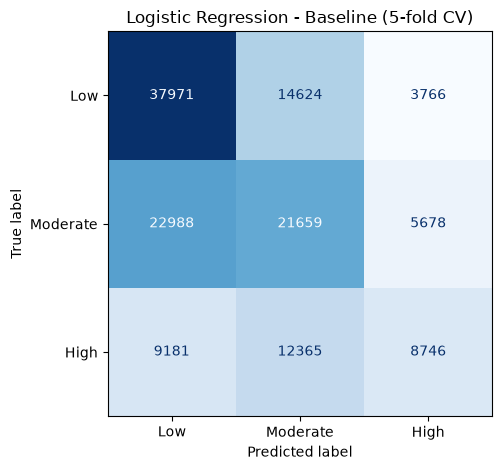

In [4]:
y_pred = cross_val_predict(baseline_model, X_train, y_train, cv=cv, n_jobs=-1)

# How many of the real High Risk cases (label 2) the model found
high_risk_recall = recall_score(y_train, y_pred, labels=[2], average="macro")
print(f"High Risk recall: {high_risk_recall:.3f}")

ConfusionMatrixDisplay.from_predictions(y_train, y_pred, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", colorbar=False)
plt.title("Logistic Regression - Baseline (5-fold CV)")
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (Stage 7)
**Search strategy: GridSearchCV.** It tries **every combination** of the settings below with the same 5-fold CV
and keeps the one with the best Macro F1. A grid search fits here because only a few important settings are tuned,
so trying all combinations is still fast enough.

| Setting | Values tried | What it controls |
|---|---|---|
| `C` | 0.01, 0.1, 1, 10 | Regularization strength. Smaller C = simpler model, larger C = fits the training data more closely |
| `class_weight` | None, balanced | `balanced` gives more weight to the smaller High Risk class |

In [5]:
param_grid = {"C": [0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]}

start = time.time()
search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train)

print("Best settings:", search.best_params_)
print(f"Best Macro F1: {search.best_score_:.4f}  ({time.time() - start:.0f}s)")

Best settings: {'C': 10, 'class_weight': None}
Best Macro F1: 0.4663  (20s)


In [6]:
# Score of every combination that was tried, best first
grid_results = pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
grid_results.columns = ["Settings", "Macro F1", "Std"]
grid_results.sort_values("Macro F1", ascending=False).round(4)

,Settings,Macro F1,Std
6,"{'C': 10, 'class_weight': None}",0.4663,0.0032
4,"{'C': 1, 'class_weight': None}",0.4663,0.0032
2,"{'C': 0.1, 'class_weight': None}",0.4658,0.0033
0,"{'C': 0.01, 'class_weight': None}",0.4637,0.0025
7,"{'C': 10, 'class_weight': 'balanced'}",0.4504,0.0025
5,"{'C': 1, 'class_weight': 'balanced'}",0.4504,0.0026
3,"{'C': 0.1, 'class_weight': 'balanced'}",0.4502,0.0025
1,"{'C': 0.01, 'class_weight': 'balanced'}",0.4502,0.0029


## 7. Baseline vs Tuned

Baseline F1    0.4663
Tuned F1       0.4663
dtype: float64
Improvement: +0.0001


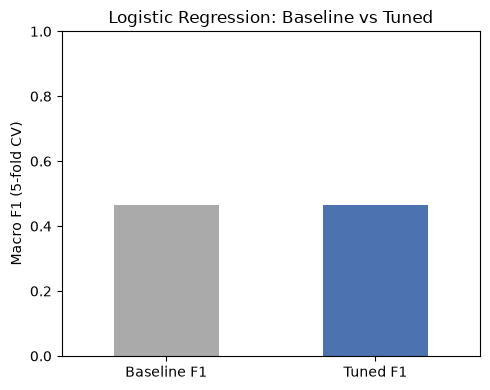

In [7]:
compare = pd.Series({
    "Baseline F1": baseline["F1 (macro)"],
    "Tuned F1": search.best_score_,
})
print(compare.round(4))
print(f"Improvement: {compare['Tuned F1'] - compare['Baseline F1']:+.4f}")

compare.plot(kind="bar", color=["#AAAAAA", "#4C72B0"], rot=0, figsize=(5, 4))
plt.title("Logistic Regression: Baseline vs Tuned")
plt.ylabel("Macro F1 (5-fold CV)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Observations
**Results**

| | Macro F1 | Train F1 | High Risk Recall |
|---|---|---|---|
| Baseline | 0.466 | 0.467 | 0.289 |
| Tuned (`C=10`, `class_weight=None`) | 0.466 | - | - |

- **Logistic Regression is the weakest of the four models.** It finds only 29% of the real High Risk cases.
- **Train F1 and validation F1 are the same (0.467 vs 0.466).** The model is not overfitting, it is **underfitting**: it is too simple for this data.
- **Why:** delay risk depends on *combinations* of features (a certain carrier at a certain airport in a certain season). A linear model adds up the effect of each feature separately and cannot learn such combinations.
- **Tuning did not help (+0.000).** Changing `C` only changes how strongly the model is regularized; it cannot turn a straight-line boundary into a curved one. `class_weight="balanced"` gave a lower Macro F1 (0.450 vs 0.466) for every value of C, so it was not used.
- **Conclusion:** Logistic Regression is useful as a simple baseline, but a non-linear model is needed for this problem.

## 9. Save the Results
These results are loaded by `Final_Model_Comparison.ipynb` to compare all four models.

In [8]:
import os
os.makedirs("results", exist_ok=True)

result_row = {
    "Model": "Logistic Regression",
    **{f"Baseline {k}": v for k, v in baseline.items()},
    "Baseline High Risk Recall": high_risk_recall,
    "Tuned F1": search.best_score_,
    "Best Params": json.dumps(search.best_params_),   # the final notebook rebuilds the model from these
}
pd.DataFrame([result_row]).to_csv("results/logistic_regression_results.csv", index=False)
print("Saved results/logistic_regression_results.csv")

Saved results/logistic_regression_results.csv
